In [2]:
from atmosphere import Atmosphere
import matplotlib.pyplot as plt
import torch
import time 

In [3]:
dtype = torch.float32
device = "cuda:0"
batch_size = 1

frame_rate = 500

telescope_resolution = 128
telescope_diameter = 3.0
telescope_samp = 2.0

wavelength = 635e-9
r0 = 0.075
L0 = 25
l0 = 1e-10

fractional_r0   = [0.5, 0.3, 0.2]   # [-]
altitude        = [0, 1e3, 10e3]    # [meters]
wind_speed      = [8.0, 10.0, 10.0] # [m/s]
wind_direction  = [0, 120, 270]     # [angle]

propagation_mode = "geometric"
delta_mode = "final"


atm = Atmosphere(batch_size = batch_size,
                 device = device,
                 dtype = dtype,

                frame_rate = frame_rate,

                telescope_diameter= telescope_diameter,
                resolution = telescope_resolution,
                wavelength = wavelength,

                r0 = r0,
                fractional_r0 = fractional_r0,
                L0 = L0,
                altitude = altitude,
                wind_speed = wind_speed,
                wind_direction = wind_direction,

                propagation_mode = propagation_mode,
                delta_mode = delta_mode 
                )

/tmp/ipykernel_1240928/3441773457.py:25: RuntimeWarning: Atmospheric layers were reordered from highest to lowest altitude.
  atm = Atmosphere(batch_size = batch_size,


In [5]:
total_samples = 50000
for n in range(total_samples):
    phase = atm.gen()

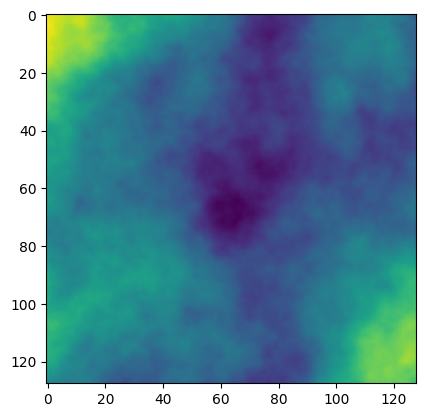

In [53]:
atm.update()
plt.imshow(phase.squeeze())